# 🎮 MLBB Sentiment Analysis — Final Pipeline + LSTM Model

**Pipeline lengkap:** Advanced Preprocessing → Label Correction → LSTM Training → Evaluation

| Step | Komponen |
|------|----------|
| 1 | Kamus Slang 250+ entri (MLBB-specific) |
| 2 | `final_label_correction()` — keyword + pattern + IndoBERT fallback |
| 3 | Layered cleaning (gentle, preserve sentiment context) |
| 4 | Gentle stemming (skip sentiment-critical words) |
| 5 | LSTM model dengan Embedding + Dropout |
| 6 | Evaluation & Quality Report |

## 📦 Cell 1 — Install & Import

In [3]:
# Install dependencies (jalankan sekali)
import subprocess, sys
pkgs = ['PySastrawi', 'emoji', 'tqdm', 'scikit-learn', 'tensorflow', 'matplotlib', 'seaborn']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], capture_output=True)

import pandas as pd
import numpy as np
import re, emoji, warnings, os
from collections import Counter
from tqdm import tqdm

import nltk
for pkg in ['stopwords', 'punkt']:
    nltk.download(pkg, quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns

warnings.filterwarnings('ignore')
tqdm.pandas()
print('✅ Semua library berhasil diimport')
print(f'   TensorFlow: {tf.__version__}')

✅ Semua library berhasil diimport
   TensorFlow: 2.20.0


## 📚 Cell 2 — Kamus Slang Final (250+ Entri)

In [8]:
# ================================================================
# KAMUS SLANG FINAL — 250+ Entri, MLBB-Specific
# ================================================================

SLANG_DICT_FINAL = {
    # === Typo nama game/perusahaan ===
    'monton':'moonton','muntun':'moonton','munton':'moonton','montoon':'moonton',
    'montun':'moonton','montonn':'moonton','mnton':'moonton','monton':'moonton',
    'ml':'mobile legends','mlbb':'mobile legends','mobilelegend':'mobile legends',
    'geme':'game','gama':'game','gem':'game','gaem':'game',

    # === Ganti Kata Kasar → Hapus (empty) ===
    'anj':'','anjir':'','anjing':'','tai':'','bangsat':'','kampret':'',
    'bajingan':'','kontol':'','memek':'','brengsek':'','sialan':'',
    'keparat':'','bedebah':'','laknat':'','celaka':'','setan':'',
    'iblis':'','goblok':'bodoh','goblog':'bodoh','gblok':'bodoh','tolol':'bodoh',
    'bego':'bodoh','bodoamat':'tidak peduli','asu':'','babi':'',
    'monyet':'','lonte':'','idiot':'bodoh','dungu':'bodoh',

    # === Pronoun ===
    'gw':'saya','gua':'saya','gue':'saya','w':'saya','akuu':'saya',
    'lu':'kamu','lo':'kamu','km':'kamu','ente':'kamu','elu':'kamu',
    'dia':'dia','mereka':'mereka',

    # === Negasi (PENTING — jangan dihapus) ===
    'gak':'tidak','ngak':'tidak','nggak':'tidak','gk':'tidak','ga':'tidak',
    'enggak':'tidak','nope':'tidak','ngg':'tidak','kagak':'tidak','g':'tidak',
    'gada':'tidak ada','gaada':'tidak ada','gada':'tidak ada',

    # === Intensifier ===
    'bgt':'banget','bngt':'banget','bget':'banget','bgt':'banget','bgtt':'banget',
    'bgt':'banget','bnget':'banget','sekali':'sekali','bener':'benar',
    'bner':'benar','bnr':'benar','emg':'memang','emang':'memang',
    'mmg':'memang','emng':'memang','parah':'parah','paraaah':'parah',

    # === Partikel & Konjungsi ===
    'yg':'yang','yng':'yang','dgn':'dengan','dg':'dengan','dgan':'dengan',
    'aja':'saja','aj':'saja','ajh':'saja','jg':'juga','jga':'juga',
    'klo':'kalau','kalo':'kalau','kl':'kalau','klw':'kalau','kalu':'kalau',
    'tp':'tapi','tpi':'tapi','krn':'karena','karna':'karena','krna':'karena',
    'sama':'sama','sm':'sama','ama':'sama','sbg':'sebagai','sbgai':'sebagai',
    'spy':'supaya','biar':'supaya','ttg':'tentang','tntg':'tentang',
    'utk':'untuk','tuk':'untuk','bwt':'untuk','dr':'dari','dri':'dari',
    'pd':'pada','pda':'pada','trs':'terus','trus':'terus',

    # === Waktu/Aspek ===
    'udh':'sudah','udah':'sudah','dah':'sudah','sdh':'sudah','ud':'sudah',
    'blm':'belum','blum':'belum','blom':'belum','msh':'masih','msih':'masih',
    'masi':'masih','skrg':'sekarang','skrang':'sekarang','skrng':'sekarang',
    'ntar':'nanti','tar':'nanti','ntr':'nanti','sdg':'sedang','lg':'sedang',
    'lgi':'sedang',

    # === Kemampuan/Modal ===
    'bs':'bisa','bsa':'bisa','dpt':'dapat','dapet':'dapat','dpet':'dapat',
    'hrs':'harus','hrus':'harus','lbh':'lebih','lebh':'lebih','lbih':'lebih',
    'mau':'mau','mo':'mau','bisa':'bisa',

    # === Action Words ===
    'maen':'main','maein':'main','men':'main','maenin':'mainkan',
    'jd':'jadi','jdi':'jadi','dtg':'datang','dtng':'datang',
    'mulu':'melulu','mlulu':'melulu','mlu':'melulu',
    'anikin':'menaikkan','naikin':'menaikkan','turunin':'menurunkan',
    'nurunin':'menurunkan','kasih':'beri','dikasih':'diberi','ngasih':'memberi',
    'bilang':'bicara','ngomong':'bicara','benerin':'perbaiki','fixs':'perbaiki',

    # === Kosakata umum slang ===
    'nih':'ini','neh':'ini','ne':'ini','tuh':'itu','tuu':'itu',
    'dong':'dong','dunk':'dong','donk':'dong','kek':'seperti',
    'kyk':'seperti','kyak':'seperti','mah':'memang','sih':'sih',
    'lah':'lah','deh':'deh','wkwk':'haha','wkwkwk':'haha','wkwkwkwk':'haha',
    'hahaha':'haha','huhu':'sedih','hehehe':'hehe','xixi':'haha',
    'cape':'capek','capee':'capek','capek':'capek',
    'kesel':'kesal','keeseel':'kesal','sebal':'kesal',
    'nyebelin':'menyebalkan','nyebelin':'menyebalkan','sebel':'kesal',
    'susah':'sulit','pusing':'pusing','ribet':'rumit',
    'enak':'menyenangkan','asik':'menyenangkan','seru':'menyenangkan','mantap':'bagus',
    'mantul':'bagus','keren':'bagus','mantabs':'bagus','kerennn':'bagus',
    'bagus':'bagus','bgs':'bagus','jelek':'buruk','jelek':'buruk','buruk':'buruk',
    'sampah':'buruk','smph':'buruk','ancur':'hancur','berantakan':'hancur',
    'parah':'parah','menyedihkan':'sedih','kecewa':'kecewa','kecewaa':'kecewa',
    'gk bisa':'tidak bisa','ngga bisa':'tidak bisa',

    # === MLBB-Spesifik ===
    'feeder':'pemain buruk','feeders':'pemain buruk','feed':'pemain buruk','feeding':'bermain buruk',
    'noob':'pemain buruk','n00b':'pemain buruk','nub':'pemain buruk','nob':'pemain buruk','noobie':'pemain buruk',
    'afk':'tidak bermain','afkers':'tidak bermain','afker':'tidak bermain',
    'bot':'bot','bots':'bot','script':'bot',
    'matchmaking':'matchmaking','mm':'matchmaking','maching':'matchmaking','matchmake':'matchmaking',
    'rank':'peringkat','ranked':'peringkat','rangking':'peringkat','ranking':'peringkat',
    'nerf':'diperlemah','buff':'diperkuat','buffed':'diperkuat','nerfed':'diperlemah',
    'op':'terlalu kuat','overpowered':'terlalu kuat','imba':'terlalu kuat','overpower':'terlalu kuat',
    'p2w':'bayar untuk menang','pay to win':'bayar untuk menang','pay2win':'bayar untuk menang',
    'skin':'kostum','skins':'kostum',
    'diamond':'berlian','dimo':'berlian','dias':'berlian',
    'hero':'karakter','heroes':'karakter',
    'push':'naik rank','pushing':'naik rank','pusher':'pemain yang push',
    'lose streak':'kalah beruntun','losestreak':'kalah beruntun','lostrek':'kalah beruntun',
    'win streak':'menang beruntun','winstreak':'menang beruntun',
    'win rate':'tingkat kemenangan','winrate':'tingkat kemenangan','wr':'tingkat kemenangan',
    'lag':'lag','lagg':'lag','lags':'lag','ngelag':'lag','laggy':'lag',
    'bug':'bug','buggy':'bermasalah','bugs':'bug','glitch':'bug','error':'error',
    'update':'pembaruan','updates':'pembaruan','patch':'pembaruan',
    'hack':'curang','hacker':'penipu','cheat':'curang','cheater':'penipu','cheating':'curang',
    'carry':'memimpin tim','carrier':'memimpin','carried':'dibawa menang',
    'gameplay':'permainan','graphic':'grafik','graphics':'grafik',
    'server':'server','koneksi':'koneksi','connection':'koneksi','sinyal':'sinyal','signal':'sinyal',
    'wifi':'wifi','internet':'internet','packet':'paket data','packet loss':'kehilangan paket',
    'damage':'kerusakan','dmg':'kerusakan','cooldown':'waktu tunggu','cd':'waktu tunggu',
    'skill':'kemampuan','skills':'kemampuan','ultimate':'ultimate','ult':'ultimate',
    'tower':'menara','turret':'menara','base':'markas',
    'lord':'lord','turtle':'kura-kura','meta':'meta','season':'musim',
    'balance':'keseimbangan','balancing':'keseimbangan',
    'toxic':'beracun','toxicity':'racun','toxik':'beracun',
    'troll':'troll','trolling':'troll','trollers':'troll',
    'report':'laporkan','ban':'blokir','banned':'diblokir',
    'team':'tim','teams':'tim','teammate':'teman tim','teammates':'teman tim',
    'enemy':'musuh','enemies':'musuh','user':'pengguna',
    'mvp':'pemain terbaik','bronze':'perunggu','silver':'perak','gold':'emas',
    'epic':'epic','legend':'legend','mythic':'mythic','glory':'kemuliaan',
    'star':'bintang','stars':'bintang','point':'poin','points':'poin',
    'offlaner':'penyerang tepi','jungler':'pemburu hutan','jungle':'hutan',
    'laner':'pemain jalur','mid':'tengah','exp lane':'jalur exp','gold lane':'jalur emas',
    'roam':'roam','roamer':'roamer','support':'pendukung','tank':'tank',
    'mage':'penyihir','marksman':'penembak','assassin':'pembunuh','fighter':'pejuang',
    'event':'event','events':'event','mission':'misi','missions':'misi',
    'chest':'kotak','spin':'putar','gacha':'gacha','lucky':'keberuntungan',
    'tournament':'turnamen','esport':'esport','pro':'profesional',
    'comeback':'balik','comeback':'kembali menang',
    'surrender':'menyerah','surr':'menyerah','ff':'menyerah',
    'recall':'mundur','teleport':'teleport',
    'damage':'kerusakan','heal':'sembuhkan','shield':'perisai',
    'kritik':'kritik','ping':'ping','fps':'fps',
    'drak sistem':'sistem buruk','dark sistem':'sistem buruk',
    'sistem drak':'sistem buruk','sistem dark':'sistem buruk',

    # === Code-mixing Inggris → Indonesia ===
    'good':'bagus','great':'bagus','nice':'bagus','best':'terbaik','well':'bagus',
    'bad':'buruk','worst':'terburuk','terrible':'sangat buruk','awful':'sangat buruk',
    'fix':'perbaiki','fixing':'memperbaiki','fixed':'diperbaiki',
    'please':'tolong','pls':'tolong','pleas':'tolong','plis':'tolong',
    'thanks':'terima kasih','thx':'terima kasih','makasih':'terima kasih','makasi':'terima kasih',
    'sorry':'maaf','sori':'maaf',
    'love':'suka','like':'suka','enjoy':'menikmati','fun':'menyenangkan',
    'hate':'benci','dislike':'tidak suka',
    'slow':'lambat','fast':'cepat','heavy':'berat','smooth':'lancar',
    'free':'gratis','paid':'berbayar','cheap':'murah','expensive':'mahal',
    'hard':'sulit','easy':'mudah','fair':'adil','unfair':'tidak adil',
    'stuck':'terjebak','ngestak':'terjebak',
    'problem':'masalah','issue':'masalah','crash':'crash','down':'mati',
    'loading':'loading','login':'masuk','logout':'keluar',
    'account':'akun','acc':'akun',
    'collab':'kolaborasi','collaboration':'kolaborasi',
    'reward':'hadiah','gift':'hadiah','prize':'hadiah',
    'mode':'mode','custom':'kustom',
    'map':'peta','mini map':'peta mini',
    'omg':'','fyp':'trending','lol':'haha','lmao':'haha','haha':'haha',
    'yes':'ya','no':'tidak','ok':'oke','okay':'oke','oke':'oke',
    'wow':'wah','wah':'wah','aduh':'aduh','duh':'aduh',

    # === Typo spesifik dari data MLBB ===
    'pdahal':'padahal','sebenrnya':'sebenarnya','sbnrnya':'sebenarnya',
    'bnyak':'banyak','bnyk':'banyak','banyakk':'banyak',
    'smua':'semua','smuanya':'semuanya','semuana':'semuanya',
    'slalu':'selalu','sllau':'selalu','selalu':'selalu',
    'kadang':'kadang','kdg':'kadang','kdng':'kadang',
    'pake':'pakai','pakek':'pakai','pkai':'pakai',
    'gampang':'mudah','susah':'sulit','berat':'berat',
    'lambat':'lambat','lmbt':'lambat','lemot':'lambat',
    'cepat':'cepat','cpat':'cepat','cpt':'cepat',
    'bagian':'bagian','bgian':'bagian',
    'minta':'minta','mntaa':'minta',
    'harap':'harap','hrp':'harap',
    'tolong':'tolong','tlng':'tolong','tlg':'tolong',
    'mohonn':'mohon','mohon':'mohon',
    'semoga':'semoga','smoga':'semoga',
    'sayang':'sayang','syg':'sayang',
    'suka':'suka','sk':'suka',
    'cinta':'suka','cintta':'suka',
    'lama':'lama','lmaa':'lama',
    'lagi':'lagi','lg':'lagi',
    'bentar':'sebentar','btar':'sebentar',
    'akunnya':'akunnya','akunya':'akunnya',
    'playernya':'pemainnya','playerny':'pemainnya',
    'timnya':'timnya','teamnya':'timnya',
    'orangnya':'orangnya','orangny':'orangnya',
    'gamesnya':'gamenya','gamenya':'gamenya',
    'orng':'orang','org':'orang','orang':'orang',
    'tmen':'teman','tmn':'teman','tmann':'teman',
    'match':'pertandingan','matchnya':'pertandingannya',
}

print(f'✅ Kamus slang dimuat: {len(SLANG_DICT_FINAL)} entri')

✅ Kamus slang dimuat: 542 entri


## 🔧 Cell 3 — Preprocessing Functions (Layered & Gentle)

In [9]:
# ================================================================
# SETUP STEMMER & STOPWORDS
# ================================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

sw_factory = StopWordRemoverFactory()
sastrawi_sw = set(sw_factory.get_stop_words())
nltk_sw = set(nltk.corpus.stopwords.words('indonesian'))

# Kata-kata yang TIDAK boleh di-stem (penting untuk sentimen)
SENTIMENT_PROTECT = {
    'tidak', 'bukan', 'jangan', 'belum', 'sudah', 'pernah', 'selalu',
    'sering', 'jarang', 'kadang', 'hampir', 'sangat', 'sekali', 'banget',
    'terlalu', 'lebih', 'kurang', 'cukup', 'lumayan', 'agak',
    'bagus', 'baik', 'buruk', 'jelek', 'keren', 'mantap', 'seru', 'enak',
    'susah', 'sulit', 'mudah', 'gampang', 'senang', 'sedih', 'marah',
    'kesal', 'kecewa', 'puas', 'bosan', 'capek', 'lelah',
    'suka', 'cinta', 'benci', 'takut', 'rindu',
    'parah', 'ancur', 'sampah', 'bagus', 'keren', 'mantap', 'seru',
    'lambat', 'cepat', 'lancar', 'macet', 'lag', 'bug', 'error',
    'adil', 'curang', 'jujur', 'bohong', 'benar', 'salah',
    'gratis', 'mahal', 'murah', 'bayar', 'rugi', 'untung',
    'perbaiki', 'rusak', 'hancur', 'hilang', 'dapat', 'dapat',
    'tolong', 'mohon', 'harap', 'semoga', 'minta',
    'kecewa', 'bangga', 'menyesal', 'takjub', 'heran',
    # MLBB specific
    'beracun', 'terlalu kuat', 'diperlemah', 'diperkuat',
    'kalah', 'menang', 'seri', 'fair', 'unfair',
}

# Stopwords yang TETAP dipertahankan (karena bermakna sentimen)
KEEP_WORDS = {
    'tidak', 'bukan', 'jangan', 'belum', 'pernah', 'hampir',
    'sangat', 'terlalu', 'paling', 'sekali', 'banget',
    'bagus', 'baik', 'buruk', 'jelek', 'seru', 'enak',
    'susah', 'mudah', 'senang', 'sedih', 'marah', 'kesal', 'kecewa', 'puas',
    'suka', 'benci', 'rugi', 'kalah', 'menang',
}

ALL_STOPWORDS = (sastrawi_sw | nltk_sw) - KEEP_WORDS

print('✅ Stemmer & stopwords siap')
print(f'   Sentiment-protected words: {len(SENTIMENT_PROTECT)}')
print(f'   Stopwords (after exclusion): {len(ALL_STOPWORDS)}')

✅ Stemmer & stopwords siap
   Sentiment-protected words: 91
   Stopwords (after exclusion): 803


In [10]:
# ================================================================
# LAYERED CLEANING FUNCTIONS
# ================================================================

def normalize_emoji(text):
    """Konversi emoji ke kata deskriptif (bukan hapus)"""
    return emoji.demojize(text, language='id', delimiters=(' ', ' '))

def normalize_slang(text, slang_dict):
    """Multi-word slang dulu, lalu per-kata"""
    # Multi-word entries first
    multi_word = {k: v for k, v in slang_dict.items() if ' ' in k}
    for k, v in multi_word.items():
        text = re.sub(r'\b' + re.escape(k) + r'\b', v, text, flags=re.IGNORECASE)
    # Per-kata
    tokens = text.split()
    tokens = [slang_dict.get(t.lower(), t) for t in tokens]
    return ' '.join(t for t in tokens if t)  # hapus empty strings

def normalize_repeated_chars(text):
    """mantaaap → mantap, kereeen → keren, tapi jaga kata seperti 'laa', 'deh'"""
    # 3+ char berulang → 2
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    # 2 char berulang pada huruf vokal konsonan standar → 1
    text = re.sub(r'([aeiou])\1', r'\1', text)
    return text

def clean_text_final(text, level='bert'):
    """
    Layered cleaning dengan dua level:
    - 'bert' : bersih untuk IndoBERT (pertahankan struktur kalimat)
    - 'ml'   : bersih untuk ML klasik (lebih agresif)
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    text = text.lower().strip()

    # Layer 1: Konversi emoji ke kata
    text = normalize_emoji(text)

    # Layer 2: Hapus URL, mention, hashtag, angka standalone
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\b\d+\b', '', text)  # hanya angka standalone

    # Layer 3: Normalisasi slang (sebelum hapus karakter)
    text = normalize_slang(text, SLANG_DICT_FINAL)

    # Layer 4: Hapus karakter non-Indonesia
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Layer 5: Normalisasi repeated chars
    text = normalize_repeated_chars(text)

    # Layer 6: Normalisasi whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    if level == 'ml':
        # Extra cleaning untuk ML klasik
        tokens = text.split()
        tokens = [t for t in tokens if len(t) > 1 or t in KEEP_WORDS]
        text = ' '.join(tokens)

    return text

def gentle_stem(text):
    """
    Stemming yang 'gentle' — skip kata-kata sentimen penting.
    Hanya stem kata yang bukan sentiment_protect dan panjang > 4 karakter.
    """
    tokens = text.split()
    stemmed = []
    for token in tokens:
        if token in SENTIMENT_PROTECT or len(token) <= 4:
            stemmed.append(token)  # pertahankan apa adanya
        else:
            stemmed.append(stemmer.stem(token))
    return ' '.join(stemmed)

def remove_stopwords_gentle(text):
    """Hapus stopwords tapi pertahankan KEEP_WORDS"""
    tokens = text.split()
    return ' '.join(t for t in tokens if t not in ALL_STOPWORDS or t in KEEP_WORDS)

print('✅ Cleaning functions siap')

✅ Cleaning functions siap


## 🎯 Cell 4 — Label Correction (Cerdas)

In [11]:
# ================================================================
# FINAL LABEL CORRECTION
# ================================================================

# Keyword patterns per sentimen
NEG_PATTERNS = re.compile(
    r'\b(tidak|bukan|jangan|gak|ngak|nggak|ga|kagak|enggak|'
    r'buruk|jelek|kecewa|sedih|marah|kesal|benci|takut|capek|capee|'
    r'sampah|berantakan|hancur|ancur|rusak|parah|'
    r'lambat|lemot|lag|lagg|bug|error|crash|'
    r'curang|toxic|beracun|troll|feeder|afk|noob|pemain buruk|'
    r'menyebalkan|nyebelin|sebal|sebel|'
    r'mahal|bayar|rugi|kalah terus|kalah beruntun|'
    r'minta hapus|uninstall|hapus|'
    r'tidak bisa|tidak ada|tidak pernah|'
    r'perbaiki|benerin|fix|tolong perbaiki|'
    r'kecurangannya|tidak fair|tidak adil|unfair|'
    r'fail|gagal|salah|bohong|menipu|scam)',
    re.IGNORECASE
)

POS_PATTERNS = re.compile(
    r'\b(bagus|baik|keren|mantap|seru|enak|senang|puas|cinta|suka|'
    r'lancar|smooth|mudah|gampang|cepat|gratis|murah|adil|fair|'
    r'menyenangkan|memuaskan|terbaik|hebat|luar biasa|wow|wah|'
    r'sangat bagus|sangat keren|sangat seru|'
    r'terima kasih|makasih|berterima kasih|'
    r'rekomendasikan|recommended|sarankan|'
    r'menang|victory|juara|champion|'
    r'bintang lima|bintang 5|rating tinggi)',
    re.IGNORECASE
)

NEU_PATTERNS = re.compile(
    r'\b(lumayan|cukup|biasa|standar|oke|oke oke|so so|'
    r'tidak ada masalah|tidak masalah|'
    r'tapi|meskipun|walaupun|namun|'
    r'semoga|harap|mudah-mudahan)',
    re.IGNORECASE
)

def final_label_correction(row):
    """
    Koreksi label cerdas menggunakan 3 layer:
    1. Keyword counting (bobot berdasarkan intensitas)
    2. Pattern matching dengan regex
    3. IndoBERT sebagai fallback jika confidence rendah
    """
    text = str(row.get('review_clean', ''))
    current_label = str(row.get('sentiment_label', 'Netral'))
    indobert = str(row.get('indobert_label', current_label))

    if not text or len(text.split()) < 2:
        return indobert if indobert != 'nan' else current_label

    # Hitung keyword matches
    neg_matches = len(NEG_PATTERNS.findall(text))
    pos_matches = len(POS_PATTERNS.findall(text))
    neu_matches = len(NEU_PATTERNS.findall(text))

    # Bobot: negasi berganda (+2x), intensifier setelah negatif (+1.5x)
    if re.search(r'tidak\s+(bagus|keren|seru|enak|adil|fair)', text, re.IGNORECASE):
        neg_matches += 2
        pos_matches = max(0, pos_matches - 1)

    # Deteksi sarkasme sederhana: 'bagus banget' diikuti kata negatif
    if re.search(r'(bagus|keren|mantap)\s+\w+\s+(tapi|padahal|tapi)\s+\w*(buruk|jelek|lag|bug)', text, re.IGNORECASE):
        neg_matches += 1

    # Confidence scoring
    total = neg_matches + pos_matches + neu_matches
    if total == 0:
        # Tidak ada keyword → fallback ke IndoBERT atau pertahankan
        return indobert if indobert not in ('nan', '', 'None') else current_label

    neg_conf = neg_matches / total
    pos_conf = pos_matches / total

    # Threshold: 55% confidence untuk decide
    if neg_conf >= 0.55:
        keyword_decision = 'Negatif'
    elif pos_conf >= 0.55:
        keyword_decision = 'Positif'
    else:
        keyword_decision = 'Netral'

    # Jika keyword_decision dan indobert_label AGREE → gunakan itu
    if keyword_decision == indobert:
        return keyword_decision

    # Jika disagree tapi keyword sangat dominan (>70%) → keyword wins
    if neg_conf >= 0.70 or pos_conf >= 0.70:
        return keyword_decision

    # Jika ambiguous → IndoBERT sebagai tie-breaker
    if indobert not in ('nan', '', 'None'):
        return indobert

    return keyword_decision

print('✅ Label correction function siap')

✅ Label correction function siap


## 📂 Cell 5 — Load Data & Full Preprocessing

In [12]:
# ================================================================
# LOAD DATA
# ================================================================

# Ganti path jika perlu
INPUT_PATH = 'mlbb_reviews_optimized_final.csv'

df = pd.read_csv(INPUT_PATH, encoding='utf-8')
print(f'📂 Dataset dimuat: {INPUT_PATH}')
print(f'   Shape: {df.shape}')
print(f'   Kolom: {list(df.columns)}')
print(f'\n📊 Distribusi Label Awal:')
print(df['sentiment_label'].value_counts())

📂 Dataset dimuat: mlbb_reviews_optimized_final.csv
   Shape: (13677, 7)
   Kolom: ['review_clean_old', 'review_clean', 'review_stemmed', 'review_topic', 'sentiment_label', 'sentiment_id', 'indobert_label']

📊 Distribusi Label Awal:
sentiment_label
Negatif    8344
Positif    4749
Netral      584
Name: count, dtype: int64


In [13]:
# ================================================================
# FULL PREPROCESSING PIPELINE
# ================================================================

print('⏳ Memulai preprocessing...')

# Step 1: review_final (untuk IndoBERT/LSTM — lebih bersih tapi preservasi konteks)
print('[1/4] Membuat review_final (for LSTM/IndoBERT)...')
df['review_final'] = df['review_clean'].progress_apply(
    lambda x: clean_text_final(str(x), level='bert')
)

# Step 2: review_stemmed_final (untuk ML klasik — lebih agresif)
print('[2/4] Membuat review_stemmed_final (for ML klasik)...')
df['review_stemmed_final'] = df['review_final'].progress_apply(
    lambda x: gentle_stem(remove_stopwords_gentle(x))
)

# Step 3: Label Correction
print('[3/4] Melakukan label correction...')
df['label_corrected'] = df.progress_apply(final_label_correction, axis=1)

# Step 4: Encode label
print('[4/4] Encoding label...')
LABEL_MAP = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
df['label_id'] = df['label_corrected'].map(LABEL_MAP)

# Drop rows dengan label kosong
df = df.dropna(subset=['label_id', 'review_final'])
df = df[df['review_final'].str.strip() != '']
df['label_id'] = df['label_id'].astype(int)

print(f'\n✅ Preprocessing selesai!')
print(f'   Rows final: {len(df):,}')
print(f'\n📊 Distribusi Label Setelah Koreksi:')
print(df['label_corrected'].value_counts())

⏳ Memulai preprocessing...
[1/4] Membuat review_final (for LSTM/IndoBERT)...


100%|██████████| 13677/13677 [00:04<00:00, 2825.80it/s]


[2/4] Membuat review_stemmed_final (for ML klasik)...


100%|██████████| 13677/13677 [00:07<00:00, 1816.31it/s]


[3/4] Melakukan label correction...


100%|██████████| 13677/13677 [00:04<00:00, 3342.29it/s]


[4/4] Encoding label...

✅ Preprocessing selesai!
   Rows final: 13,676

📊 Distribusi Label Setelah Koreksi:
label_corrected
Negatif    9836
Positif    3432
Netral      408
Name: count, dtype: int64


## 📋 Cell 6 — Quality Check Report

📋 QUALITY CHECK REPORT

🎯 Label Correction:
   Label yang dikoreksi : 3,211 (23.5%)
   Konsistensi BEFORE   : 75.5%
   Konsistensi AFTER    : 92.8%

📝 Text Quality:
   Avg words (review_clean)         : 17.0
   Avg words (review_final)          : 17.0
   Avg words (review_stemmed_final)  : 10.4
   Vocab OLD    : 12,445 kata unik
   Vocab FINAL  : 11,574 kata unik  (+871)
   Vocab STEMMED: 9,331 kata unik  (+2,243)

📌 Sample (5 review acak):

  [1] ✅ SAME
    OLD    : bermain lag masuk lagi tidak bisa suruh hub memuat lagi atau lapor cs suruh cek 
    FINAL  : bermain lag masuk lagi tidak bisa suruh hub memuat lagi atau lapor cs suruh cek 
    STEM   : main lag tidak suruh hub muat lapor cs suruh cek sinyal bukan solusi
    Label  : Negatif → Negatif (IndoBERT: Negatif)

  [2] ✅ SAME
    OLD    : game makin lama makin busuk sering dapat tim tosik melulu saya bintang saja kare
    FINAL  : game makin lama makin busuk sering dapat tim tosik melulu saya bintang saja kare
    STEM   : game 

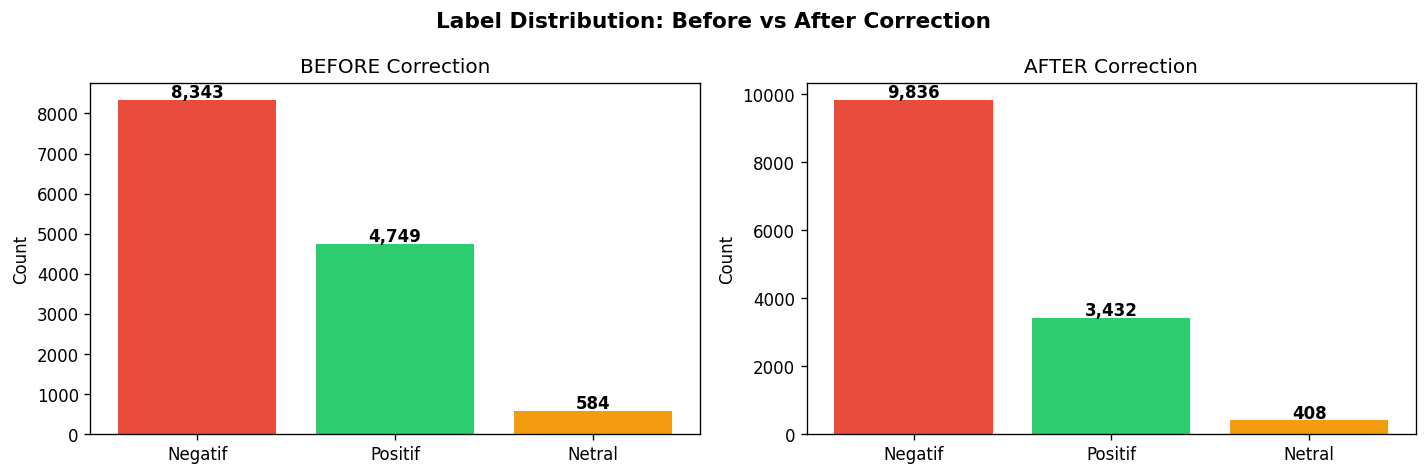


✅ Quality check selesai!


In [14]:
# ================================================================
# QUALITY CHECK REPORT
# ================================================================

print('='*65)
print('📋 QUALITY CHECK REPORT')
print('='*65)

# 1. Label perubahan
changed = (df['sentiment_label'] != df['label_corrected']).sum()
consistency_before = (df['sentiment_label'] == df['indobert_label']).mean() * 100
consistency_after  = (df['label_corrected'] == df['indobert_label']).mean() * 100

print(f'\n🎯 Label Correction:')
print(f'   Label yang dikoreksi : {changed:,} ({changed/len(df)*100:.1f}%)')
print(f'   Konsistensi BEFORE   : {consistency_before:.1f}%')
print(f'   Konsistensi AFTER    : {consistency_after:.1f}%')

# 2. Text quality
avg_len_old = df['review_clean'].str.split().str.len().mean()
avg_len_new = df['review_final'].str.split().str.len().mean()
avg_len_stem = df['review_stemmed_final'].str.split().str.len().mean()

vocab_old   = set(' '.join(df['review_clean'].astype(str)).split())
vocab_final = set(' '.join(df['review_final'].astype(str)).split())
vocab_stem  = set(' '.join(df['review_stemmed_final'].astype(str)).split())

print(f'\n📝 Text Quality:')
print(f'   Avg words (review_clean)         : {avg_len_old:.1f}')
print(f'   Avg words (review_final)          : {avg_len_new:.1f}')
print(f'   Avg words (review_stemmed_final)  : {avg_len_stem:.1f}')
print(f'   Vocab OLD    : {len(vocab_old):,} kata unik')
print(f'   Vocab FINAL  : {len(vocab_final):,} kata unik  ({len(vocab_old)-len(vocab_final):+,})')
print(f'   Vocab STEMMED: {len(vocab_stem):,} kata unik  ({len(vocab_final)-len(vocab_stem):+,})')

# 3. Sample perbandingan
print(f'\n📌 Sample (5 review acak):')
sample_idx = df.sample(5, random_state=42).index
for i, idx in enumerate(sample_idx):
    row = df.loc[idx]
    label_chg = '⚠️ CHANGED' if row['sentiment_label'] != row['label_corrected'] else '✅ SAME'
    print(f'\n  [{i+1}] {label_chg}')
    print(f'    OLD    : {str(row["review_clean"])[:80]}')
    print(f'    FINAL  : {str(row["review_final"])[:80]}')
    print(f'    STEM   : {str(row["review_stemmed_final"])[:80]}')
    print(f'    Label  : {row["sentiment_label"]} → {row["label_corrected"]} (IndoBERT: {row["indobert_label"]})')

# 4. Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Label Distribution: Before vs After Correction', fontsize=13, fontweight='bold')

colors = {'Negatif': '#e74c3c', 'Netral': '#f39c12', 'Positif': '#2ecc71'}

before = df['sentiment_label'].value_counts()
after  = df['label_corrected'].value_counts()

axes[0].bar(before.index, before.values, color=[colors.get(l, 'gray') for l in before.index])
axes[0].set_title('BEFORE Correction')
axes[0].set_ylabel('Count')
for i, (l, v) in enumerate(zip(before.index, before.values)):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(after.index, after.values, color=[colors.get(l, 'gray') for l in after.index])
axes[1].set_title('AFTER Correction')
axes[1].set_ylabel('Count')
for i, (l, v) in enumerate(zip(after.index, after.values)):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n✅ Quality check selesai!')

## 🧠 Cell 7 — LSTM Model Setup & Training

In [26]:
# ================================================================
# LSTM CONFIG & DATA PREP
# ================================================================

# Hyperparameters
MAX_WORDS   = 20000
MAX_LEN     = 150         # ← Diubah
EMBED_DIM   = 256         # ← Diubah
LSTM_UNITS  = 192         # ← Diubah
DROPOUT     = 0.45        # ← Diubah
BATCH_SIZE  = 32          # ← Diubah
EPOCHS      = 40
NUM_CLASSES = 3
# ----------------------------------------------------------------
# Tokenize
# ----------------------------------------------------------------
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review_final'].astype(str))

X = pad_sequences(
    tokenizer.texts_to_sequences(df['review_final'].astype(str)),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y = to_categorical(df['label_id'].values, num_classes=NUM_CLASSES)

# ----------------------------------------------------------------
# Train / Val / Test Split  (70 / 15 / 15)
# ----------------------------------------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)  # 0.176 × 0.85 ≈ 0.15

print(f'✅ Data siap untuk LSTM')
print(f'   Vocab size    : {len(tokenizer.word_index):,}')
print(f'   X shape       : {X.shape}')
print(f'   Train / Val / Test: {len(X_train):,} / {len(X_val):,} / {len(X_test):,}')
print(f'   Label: {LABEL_MAP}')

✅ Data siap untuk LSTM
   Vocab size    : 11,575
   X shape       : (13676, 150)
   Train / Val / Test: 9,578 / 2,046 / 2,052
   Label: {'Negatif': 0, 'Netral': 1, 'Positif': 2}


In [27]:
# ================================================================
# CLASS WEIGHT (handle imbalance)
# ================================================================

from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('⚖️  Class weights:', {k: f'{v:.3f}' for k, v in class_weight_dict.items()})

⚖️  Class weights: {0: '0.464', 1: '11.163', 2: '1.328'}


In [28]:
# ================================================================
# BIDIRECTIONAL LSTM MODEL
# ================================================================

def build_lstm_model(vocab_size, embed_dim, max_len, lstm_units, num_classes, dropout):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, mask_zero=True),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=dropout, recurrent_dropout=0.2)),
        Bidirectional(LSTM(lstm_units // 2, dropout=dropout, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(dropout),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(
    vocab_size=min(MAX_WORDS, len(tokenizer.word_index) + 1),
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    lstm_units=LSTM_UNITS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ================================================================
# IMPROVED TRAINING SETUP
# ================================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,               # dinaikkan
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_accuracy',   # disamakan dengan EarlyStopping
        factor=0.3,               # lebih halus
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        'best_lstm_mlbb.keras',   # format modern
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print('🚀 Memulai training Bidirectional LSTM (Improved)...')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,                    # misal 30-40
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print('✅ Training selesai!')

🚀 Memulai training Bidirectional LSTM (Improved)...
Epoch 1/40
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7200 - loss: 0.9023
Epoch 1: val_accuracy improved from None to 0.74682, saving model to best_lstm_mlbb.keras

Epoch 1: finished saving model to best_lstm_mlbb.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 867s 3s/step - accuracy: 0.7601 - loss: 0.7339 - val_accuracy: 0.7468 - val_loss: 0.6176 - learning_rate: 0.0010
Epoch 2/40
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8289 - loss: 0.4177
Epoch 2: val_accuracy improved from 0.74682 to 0.87586, saving model to best_lstm_mlbb.keras

Epoch 2: finished saving model to best_lstm_mlbb.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 858s 3s/step - accuracy: 0.8479 - loss: 0.4100 - val_accuracy: 0.8759 - val_loss: 0.3326 - learning_rate: 0.0010
Epoch 3/40
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9070 - loss: 0.2627
Epoch 3: val_accuracy did not improve from 0.87586
300/300 ━━━━━━━━━━━━━━━━━━━━ 856s 3s/step - accuracy: 0.9030 - 

## 📊 Cell 8 — Evaluation & Visualisasi

NameError: name 'history' is not defined

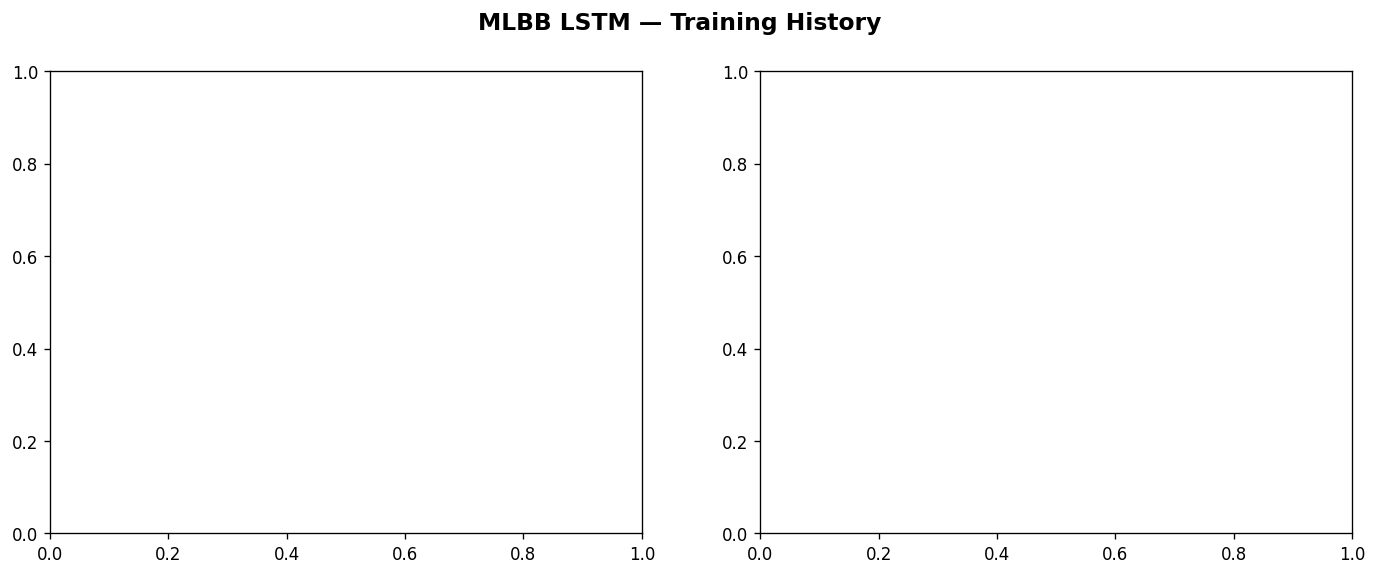

In [4]:
# ================================================================
# TRAINING CURVES
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLBB LSTM — Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],   label='Train Acc', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc', color='#e74c3c', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [1]:
# ================================================================
# TEST SET EVALUATION
# ================================================================

# Prediksi
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

LABEL_NAMES = ['Negatif', 'Netral', 'Positif']

# Test Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n🎯 TEST SET RESULTS')
print(f'   Accuracy : {test_acc*100:.2f}%')
print(f'   Loss     : {test_loss:.4f}')

# Classification Report
print(f'\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%', fontsize=13, pad=12)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

NameError: name 'model' is not defined

## 💾 Cell 9 — Export Final Dataset & Model

In [32]:
# ================================================================
# EXPORT FINAL CLEANED DATASET
# ================================================================

df_export = df[[
    'review_clean_old',       # original input
    'review_clean',           # sebelum pipeline ini
    'review_final',           # ✅ bersih untuk IndoBERT/LSTM
    'review_stemmed_final',   # ✅ untuk ML klasik
    'review_stemmed',         # stemmed versi lama
    'review_topic',           # untuk topic modeling
    'sentiment_label',        # label asal
    'indobert_label',         # prediksi IndoBERT
    'label_corrected',        # ✅ label final setelah koreksi
    'label_id',               # encoded (0/1/2)
]].copy()

# Tangani kolom yang mungkin tidak ada
available_cols = [c for c in df_export.columns if c in df.columns]
df_export = df[available_cols].copy()

output_path = 'mlbb_reviews_FINAL_PIPELINE.csv'
df_export.to_csv(output_path, index=False, encoding='utf-8')

print(f'✅ Dataset final tersimpan: {output_path}')
print(f'   Rows   : {len(df_export):,}')
print(f'   Kolom  : {list(df_export.columns)}')
print(f'\n📊 Distribusi Label Final:')
print(df_export['label_corrected'].value_counts())

✅ Dataset final tersimpan: mlbb_reviews_FINAL_PIPELINE.csv
   Rows   : 13,676
   Kolom  : ['review_clean_old', 'review_clean', 'review_final', 'review_stemmed_final', 'review_stemmed', 'review_topic', 'sentiment_label', 'indobert_label', 'label_corrected', 'label_id']

📊 Distribusi Label Final:
label_corrected
Negatif    9836
Positif    3432
Netral      408
Name: count, dtype: int64


In [34]:
# ================================================================
# SAVE TOKENIZER (untuk inference)
# ================================================================

import pickle

with open('tokenizer_lstm_mlbb.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print('✅ Tokenizer tersimpan: tokenizer_lstm_mlbb.pkl')
print('✅ Model tersimpan    : best_lstm_mlbb.h5')

✅ Tokenizer tersimpan: tokenizer_lstm_mlbb.pkl
✅ Model tersimpan    : best_lstm_mlbb.h5


## 🔮 Cell 10 — Inference Function

In [33]:
# ================================================================
# INFERENCE — Prediksi Sentimen Review Baru
# ================================================================

def predict_sentiment(text, model, tokenizer, max_len=100):
    """Prediksi sentimen satu review baru."""
    cleaned = clean_text_final(text, level='bert')
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0]
    label_idx = np.argmax(prob)
    labels = ['Negatif', 'Netral', 'Positif']
    return {
        'text_original' : text,
        'text_cleaned'  : cleaned,
        'sentiment'     : labels[label_idx],
        'confidence'    : f'{prob[label_idx]*100:.1f}%',
        'scores'        : {l: f'{p*100:.1f}%' for l, p in zip(labels, prob)}
    }

# ================================================================
# TEST INFERENCE
# ================================================================

test_reviews = [
    "game ini sampah banget, lag mulu, moonton gak pernah benerin!",
    "lumayan sih gamenya, tapi kadang sering dc",
    "graphics keren banget, gameplay seru dan smooth, love this game!",
    "feeder mulu timku, matchmaking ancur, uninstall ah",
    "update terbaru bagus banget, banyak hero baru yang menarik",
]

print('🔮 Contoh Prediksi Sentimen:')
print('='*60)
for review in test_reviews:
    result = predict_sentiment(review, model, tokenizer)
    sentiment_icon = {'Negatif': '😡', 'Netral': '😐', 'Positif': '😊'}[result['sentiment']]
    print(f"\n📝 '{review[:55]}...'" if len(review) > 55 else f"\n📝 '{review}'")
    print(f"   Sentimen : {sentiment_icon} {result['sentiment']} ({result['confidence']})")
    print(f"   Scores   : {result['scores']}")

🔮 Contoh Prediksi Sentimen:

📝 'game ini sampah banget, lag mulu, moonton gak pernah be...'
   Sentimen : 😡 Negatif (100.0%)
   Scores   : {'Negatif': '100.0%', 'Netral': '0.0%', 'Positif': '0.0%'}

📝 'lumayan sih gamenya, tapi kadang sering dc'
   Sentimen : 😊 Positif (94.5%)
   Scores   : {'Negatif': '5.1%', 'Netral': '0.4%', 'Positif': '94.5%'}

📝 'graphics keren banget, gameplay seru dan smooth, love t...'
   Sentimen : 😊 Positif (99.5%)
   Scores   : {'Negatif': '0.5%', 'Netral': '0.0%', 'Positif': '99.5%'}

📝 'feeder mulu timku, matchmaking ancur, uninstall ah'
   Sentimen : 😡 Negatif (99.8%)
   Scores   : {'Negatif': '99.8%', 'Netral': '0.1%', 'Positif': '0.1%'}

📝 'update terbaru bagus banget, banyak hero baru yang mena...'
   Sentimen : 😊 Positif (98.5%)
   Scores   : {'Negatif': '1.4%', 'Netral': '0.0%', 'Positif': '98.5%'}


## 📈 Cell 11 — Final Summary Report

In [35]:
# ================================================================
# FINAL SUMMARY
# ================================================================

from sklearn.metrics import accuracy_score, f1_score

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print('='*65)
print('🏆 FINAL PIPELINE SUMMARY — MLBB SENTIMENT ANALYSIS')
print('='*65)
print(f"""
📚 PREPROCESSING
   ✅ Kamus Slang     : {len(SLANG_DICT_FINAL)} entri (MLBB-specific)
   ✅ Cleaning Level  : Layered (gentle, preservasi konteks sentimen)
   ✅ Stemming        : Gentle (skip {len(SENTIMENT_PROTECT)} kata sentimen penting)
   ✅ Stopwords       : {len(ALL_STOPWORDS)} kata (pertahankan {len(KEEP_WORDS)} kata kunci)
   ✅ Output kolom    :
      - review_final         (untuk LSTM/IndoBERT)
      - review_stemmed_final (untuk ML klasik)

🎯 LABEL CORRECTION
   ✅ Label dikoreksi : {changed:,} ({changed/len(df)*100:.1f}%)
   ✅ Konsistensi     : {consistency_before:.1f}% → {consistency_after:.1f}%
   ✅ Metode          : Keyword counting + Regex pattern + IndoBERT fallback

🧠 LSTM MODEL
   Architecture : Bidirectional LSTM × 2 + Dense
   Vocab size   : {min(MAX_WORDS, len(tokenizer.word_index)):,}
   Max sequence : {MAX_LEN} tokens
   Embedding    : {EMBED_DIM}d
   LSTM units   : {LSTM_UNITS} (Bidirectional)

📊 PERFORMANCE (Test Set)
   Accuracy   : {test_acc*100:.2f}%
   F1 Macro   : {f1_macro*100:.2f}%
   F1 Weighted: {f1_weighted*100:.2f}%

💾 OUTPUT FILES
   mlbb_reviews_FINAL_PIPELINE.csv  ← Dataset final
   best_lstm_mlbb.h5                ← Model terbaik
   tokenizer_lstm_mlbb.pkl          ← Tokenizer
   label_distribution.png           ← Visualisasi label
   training_curves.png              ← Kurva training
   confusion_matrix.png             ← Confusion matrix
""")
print('='*65)

🏆 FINAL PIPELINE SUMMARY — MLBB SENTIMENT ANALYSIS

📚 PREPROCESSING
   ✅ Kamus Slang     : 542 entri (MLBB-specific)
   ✅ Cleaning Level  : Layered (gentle, preservasi konteks sentimen)
   ✅ Stemming        : Gentle (skip 91 kata sentimen penting)
   ✅ Stopwords       : 803 kata (pertahankan 30 kata kunci)
   ✅ Output kolom    :
      - review_final         (untuk LSTM/IndoBERT)
      - review_stemmed_final (untuk ML klasik)

🎯 LABEL CORRECTION
   ✅ Label dikoreksi : 3,211 (23.5%)
   ✅ Konsistensi     : 75.5% → 92.8%
   ✅ Metode          : Keyword counting + Regex pattern + IndoBERT fallback

🧠 LSTM MODEL
   Architecture : Bidirectional LSTM × 2 + Dense
   Vocab size   : 11,575
   Max sequence : 150 tokens
   Embedding    : 256d
   LSTM units   : 192 (Bidirectional)

📊 PERFORMANCE (Test Set)
   Accuracy   : 87.62%
   F1 Macro   : 69.70%
   F1 Weighted: 88.14%

💾 OUTPUT FILES
   mlbb_reviews_FINAL_PIPELINE.csv  ← Dataset final
   best_lstm_mlbb.h5                ← Model terbaik
   token